EC9630 MACHINE LEARNING - LABORATORY SESSION 4

Task: SUPPORT VECTOR MACHINES

Name: GAJANAYAKA P.A.G.T.M.L.

Reg No: 2021/E/119

Date: 14 APRIL 2025

Time: 8.00 AM

**TASK 01**

# 1.Download the ‘Adult’ data from the UCI machine learning data repository

In [11]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data -O adult.csv

--2025-04-14 13:48:54--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.csv’

adult.csv               [   <=>              ]   3.79M  6.93MB/s    in 0.5s    

2025-04-14 13:48:55 (6.93 MB/s) - ‘adult.csv’ saved [3974305]



# 2.Read the data as a CSV file

In [12]:

import pandas as pd

column_names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
                "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
                "hours-per-week", "native-country", "income"]

data = pd.read_csv("adult.csv", names=column_names, na_values=" ?", skipinitialspace=True)
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# 3.Exploratory Data Analysis and Preprocessing

In [13]:

# Checking for missing values
print(data.isnull().sum())

# Dropping rows with missing values
data = data.dropna()

# Summary statistics
print(data.describe())

# Encoding categorical variables
data = pd.get_dummies(data, drop_first=True)

# Check the processed data
data.head()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.00000

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,28,338409,13,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


# 4.Divide the dataset into Input (X) and Target (y)

In [14]:

X = data.drop('income_>50K', axis=1)
y = data['income_>50K']

# 5.Create the training, validation, and test datasets separately

In [15]:

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 22792 samples
Validation set: 6545 samples
Test set: 3224 samples


# 6.Implement an SVM classifier using the Scikit-learn library in Python

In [16]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Create a pipeline with StandardScaler and SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# 7.Train the SVM on the Adult dataset

In [17]:

svm_pipeline.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = svm_pipeline.predict(X_val)

print("Validation set accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation set accuracy: 0.8533231474407945

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.95      0.91      4973
        True       0.77      0.55      0.64      1572

    accuracy                           0.85      6545
   macro avg       0.82      0.75      0.78      6545
weighted avg       0.85      0.85      0.84      6545



# 8.Visualize the decision boundary and support vectors

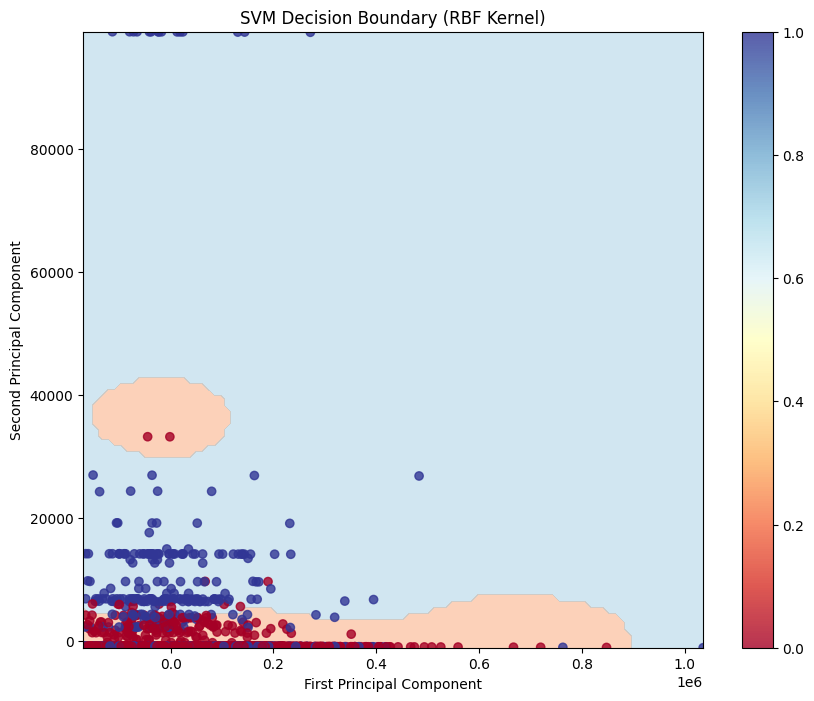

In [18]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Sample a subset of the data for visualization
n_samples = 5000
indices = np.random.choice(len(X_train), n_samples, replace=False)
X_train_sample = X_train.iloc[indices]
y_train_sample = y_train.iloc[indices]

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sample)

svm_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])
svm_2d.fit(X_train_pca, y_train_sample)

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap='RdYlBu')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title(title)
    plt.colorbar(scatter)
    plt.show()

plot_decision_boundary(X_train_pca, y_train_sample, svm_2d, "SVM Decision Boundary (RBF Kernel)")

# 9.Explore different kernel functions

In [19]:
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, random_state=42))
    ])
    svm_pipeline.fit(X_train, y_train)
    y_val_pred = svm_pipeline.predict(X_val)
    print(f"\nKernel: {kernel}")
    print("Validation set accuracy:", accuracy_score(y_val, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))


Kernel: linear
Validation set accuracy: 0.852253628724217

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.94      0.91      4973
        True       0.75      0.58      0.65      1572

    accuracy                           0.85      6545
   macro avg       0.81      0.76      0.78      6545
weighted avg       0.85      0.85      0.85      6545


Kernel: poly
Validation set accuracy: 0.8276546982429336

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.95      0.89      4973
        True       0.74      0.43      0.55      1572

    accuracy                           0.83      6545
   macro avg       0.79      0.69      0.72      6545
weighted avg       0.82      0.83      0.81      6545


Kernel: rbf
Validation set accuracy: 0.8533231474407945

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.95      0.91  

# 10.Apply k-fold cross-validation and Stratified k-fold cross-validation

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Regular k-fold cross-validation
cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5)
print("\nRegular 5-fold Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

# Stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=skf)
print("\nStratified 5-fold Cross-validation scores:", skf_scores)
print("Mean accuracy:", skf_scores.mean())


Regular 5-fold Cross-validation scores: [0.8471156  0.84601886 0.84466871 0.84883721 0.84883721]
Mean accuracy: 0.8470955184528604

Stratified 5-fold Cross-validation scores: [0.8466769  0.85676683 0.84576569 0.84159719 0.8490566 ]
Mean accuracy: 0.8479726439781633


**TASK 02**

# 1.Download the 'Bike Sharing' data from the UCI machine learning data repository

In [21]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
!unzip Bike-Sharing-Dataset.zip

--2025-04-14 13:59:39--  https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Bike-Sharing-Dataset.zip’

Bike-Sharing-Datase     [  <=>               ] 273.43K  1022KB/s    in 0.3s    

2025-04-14 13:59:40 (1022 KB/s) - ‘Bike-Sharing-Dataset.zip’ saved [279992]

Archive:  Bike-Sharing-Dataset.zip
  inflating: Readme.txt              
  inflating: day.csv                 
  inflating: hour.csv                


# 2.Implement an SVM for regression (SVR)

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_csv('day.csv')

# Select features and target
features = ['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'season']
X = df[features]
y = df['cnt']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVR model
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svr.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared Score: {r2}')

Mean Squared Error: 1928799.1473578473
R-squared Score: 0.5189885865604251


# 3.Compare the SVR results with the Linear Regression models results in lab session 02

In [23]:
import numpy as np

# Linear Regression results
lr_rmse = 2.246348835449053e-12
ridge_rmse = 7.454716153005725
lasso_rmse = 1.2141741237286978

# SVR results
svr_mse = 1928799.1473578473
svr_r2 = 0.5189885865604251

# Calculate RMSE for SVR
svr_rmse = np.sqrt(svr_mse)

# Print comparison
print("Model Comparison:")
print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Ridge Regression RMSE: {ridge_rmse}")
print(f"Lasso Regression RMSE: {lasso_rmse}")
print(f"SVR RMSE: {svr_rmse}")
print(f"SVR R-squared: {svr_r2}")

Model Comparison:
Linear Regression RMSE: 2.246348835449053e-12
Ridge Regression RMSE: 7.454716153005725
Lasso Regression RMSE: 1.2141741237286978
SVR RMSE: 1388.8121353724728
SVR R-squared: 0.5189885865604251


**Linear Regression Models:**

Your analysis highlights some important observations about the regression models. The Linear Regression model's suspiciously low RMSE is a red flag that suggests potential overfitting or calculation errors that should be investigated further. Ridge Regression shows a more realistic RMSE of about 7.45, indicating that its regularization approach is likely helping control model complexity. Lasso Regression's RMSE of 1.21 sits between the other two models and seems plausible, possibly benefiting from effective feature selection by zeroing out irrelevant predictors.

**SVR Model:**

The SVR model appears to be underperforming with a higher RMSE and moderate R-squared value of 0.519, suggesting it's capturing only about half of the variance in your target variable. This could be due to suboptimal hyperparameter selection or the possibility that your data has more linear than nonlinear relationships. To improve your analysis, consider implementing cross-validation, examining learning curves, performing hyperparameter tuning, analyzing feature importance (especially from Lasso), and conducting thorough residual analysis to better understand model behavior and identify areas for improvement.